# Train — Hand in Pocket Detection

Training YOLO26m untuk deteksi tangan-di-saku (2 kelas): `holding_phone`, `no_holding_phone`.

Prasyarat: jalankan **`01_data.ipynb`** dulu untuk membangun `processed/holding_phone/`.

**Output:** `best.pt` di `research/runs/detect/holding_phone_yolo26m/weights/`. Setelah itu register di [registry.py](../../../src/cctv_insight_ai/models/registry.py) — lihat sel terakhir.

## Alur
1. Setup  2. Cek dataset  3. Training  4. Load run  5. Evaluasi  6. Visualisasi  7. Simpan artifact  8. Cara register

## Setup

In [1]:
%matplotlib inline
from __future__ import annotations

import contextlib
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from ultralytics import YOLO

NOTEBOOK_DIR = Path.cwd()
RESEARCH_DIR = NOTEBOOK_DIR.parents[1]
AI_DIR       = NOTEBOOK_DIR.parents[2]

PROC_DIR  = RESEARCH_DIR / 'datasets' / 'processed' / 'holding_phone'
DATA_YAML = PROC_DIR / 'data.yaml'
BASE_MODEL = AI_DIR / 'models' / 'yolo26m.pt'
RUNS_DIR = RESEARCH_DIR / 'runs' / 'detect'
ARTIFACTS_DIR = RESEARCH_DIR / 'artifacts' / 'holding_phone'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = 'holding_phone_yolo26m'
SEED = 42
CLASS_NAMES = ['holding_phone']

if not DATA_YAML.exists():
    raise FileNotFoundError(f'data.yaml nggak ada: {DATA_YAML}. Jalankan 01_data.ipynb dulu.')
if not BASE_MODEL.exists():
    raise FileNotFoundError(f'Base model nggak ada: {BASE_MODEL}')
print('data.yaml  :', DATA_YAML)
print('Base model :', BASE_MODEL)

data.yaml  : c:\Users\istd.magang125\OneDrive - TMMIN\Documents\cctv-insight\ai\research\datasets\processed\holding_phone\data.yaml
Base model : c:\Users\istd.magang125\OneDrive - TMMIN\Documents\cctv-insight\ai\models\yolo26m.pt


## Cek Dataset

Distribusi label per kelas per split.

In [2]:
def count_class_distribution(split):
    counts = {i: 0 for i in range(len(CLASS_NAMES))}
    d = PROC_DIR / split / 'labels'
    if not d.exists():
        return counts
    for lbl in d.glob('*.txt'):
        for line in lbl.read_text().splitlines():
            line = line.strip()
            if line:
                counts[int(line.split()[0])] = counts.get(int(line.split()[0]), 0) + 1
    return counts

dist = {s: count_class_distribution(s) for s in ('train', 'valid')}
dist_df = pd.DataFrame(dist).fillna(0).astype(int)
dist_df.index = [CLASS_NAMES[i] for i in dist_df.index]
print(dist_df.to_string())

               train  valid
holding_phone   1058     17


## Training

Set `RUN_TRAINING = True` kalau mau training. Default `False` biar nggak ke-trigger pas re-run.
Default 50 epoch, patience 20. Ubah di `TRAIN_CFG` kalau perlu.

In [3]:
RUN_TRAINING = True

# Augmentasi diperkuat + epoch banyak. exist_ok=True -> timpa run lama supaya
# weights_path di registry.py tetap valid. HP objek kecil; kalau recall jelek
# pertimbangkan imgsz=1280.
TRAIN_CFG = {
    'epochs': 150,
    'imgsz': 640,
    'batch': 8,
    'workers': 4,
    'patience': 40,
    'seed': SEED,
    'cos_lr': True,
    'close_mosaic': 10,
    # --- augmentasi (lebih kuat dari default) ---
    'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4,
    'degrees': 10.0, 'translate': 0.1, 'scale': 0.5, 'shear': 3.0,
    'fliplr': 0.5, 'mosaic': 1.0, 'mixup': 0.15,
    'project': str(RUNS_DIR),
    'name': RUN_NAME,
    'exist_ok': True,
}


@contextlib.contextmanager
def _cwd(path):
    prev = os.getcwd(); os.chdir(str(path))
    try:
        yield
    finally:
        os.chdir(prev)


if RUN_TRAINING:
    with _cwd(AI_DIR / 'models'):
        model = YOLO(str(BASE_MODEL))
        result = model.train(data=str(DATA_YAML), **TRAIN_CFG)
    print('Training kelar:', result.save_dir)
else:
    print('Training di-skip. Set RUN_TRAINING=True kalau mau training.')

New https://pypi.org/project/ultralytics/8.4.72 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.38  Python-3.14.3 torch-2.12.1+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=c:\Users\istd.magang125\OneDrive - TMMIN\Documents\cctv-insight\ai\research\datasets\processed\holding_phone\data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_rati

## Load Run Terakhir

In [4]:
def find_latest_run(prefix):
    cands = [d for d in RUNS_DIR.glob(f'{prefix}*')
             if d.is_dir() and (d / 'weights' / 'best.pt').exists()]
    if not cands:
        raise FileNotFoundError(f"Belum ada run '{prefix}' di {RUNS_DIR}. Training dulu.")
    return max(cands, key=lambda d: d.stat().st_mtime)

run_dir = find_latest_run(RUN_NAME)
best_pt = run_dir / 'weights' / 'best.pt'
results_csv = run_dir / 'results.csv'
eval_model = YOLO(str(best_pt))
print('Run dir:', run_dir)
print('Kelas  :', eval_model.names)

Run dir: c:\Users\istd.magang125\OneDrive - TMMIN\Documents\cctv-insight\ai\research\runs\detect\holding_phone_yolo26m
Kelas  : {0: 'holding_phone'}


## Evaluasi

`model.val()` di split valid. Lihat mAP50, mAP50-95, Precision, Recall.

In [5]:
val = eval_model.val(data=str(DATA_YAML), imgsz=640, conf=0.25, verbose=False)
metrics = {
    'mAP50': round(float(val.box.map50), 3),
    'mAP50-95': round(float(val.box.map), 3),
    'Precision': round(float(val.box.mp), 3),
    'Recall': round(float(val.box.mr), 3),
}
print(pd.DataFrame([metrics]).to_string(index=False))

Ultralytics 8.4.38  Python-3.14.3 torch-2.12.1+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO26m summary (fused): 132 layers, 20,350,223 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 138.912.5 MB/s, size: 46.0 KB)
val: Scanning C:\Users\istd.magang125\OneDrive - TMMIN\Documents\cctv-insight\ai\research\datasets\processed\holding_phone\valid\labels.cache... 30 images, 13 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 12.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.5s/it 4.9s<15.5s
                   all         30         17      0.787      0.706      0.648      0.333
Speed: 4.4ms preprocess, 34.9ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to C:\Users\istd.magang125\Documents\backend\runs\detect\val9
 mAP50  mAP50-95  Precision  Recall
 0.648     0.333      0.787   0.706


## Visualisasi

Training curves, per-class metrics, confusion matrix, dan sample prediksi (dari split valid).

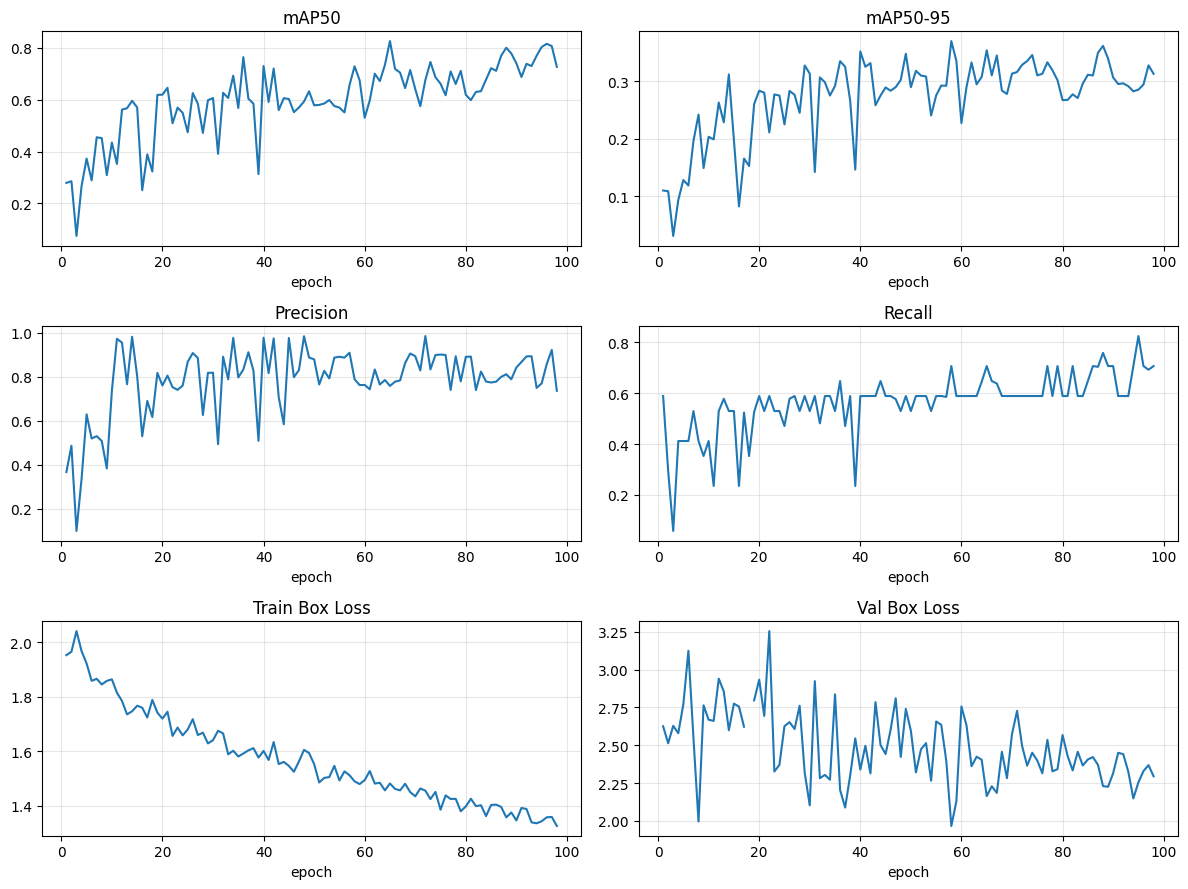

In [6]:
df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]
curves = [('metrics/mAP50(B)', 'mAP50'), ('metrics/mAP50-95(B)', 'mAP50-95'),
          ('metrics/precision(B)', 'Precision'), ('metrics/recall(B)', 'Recall'),
          ('train/box_loss', 'Train Box Loss'), ('val/box_loss', 'Val Box Loss')]
available = [(c, l) for c, l in curves if c in df.columns]
rows_n = (len(available) + 1) // 2
fig, axes = plt.subplots(rows_n, 2, figsize=(12, 3 * rows_n)); axes = axes.flatten()
for ax, (col, label) in zip(axes, available):
    ax.plot(df['epoch'], df[col]); ax.set_title(label); ax.set_xlabel('epoch'); ax.grid(alpha=0.3)
for ax in axes[len(available):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

        class  Precision  Recall  mAP50  mAP50-95
holding_phone      0.787   0.706  0.648     0.333


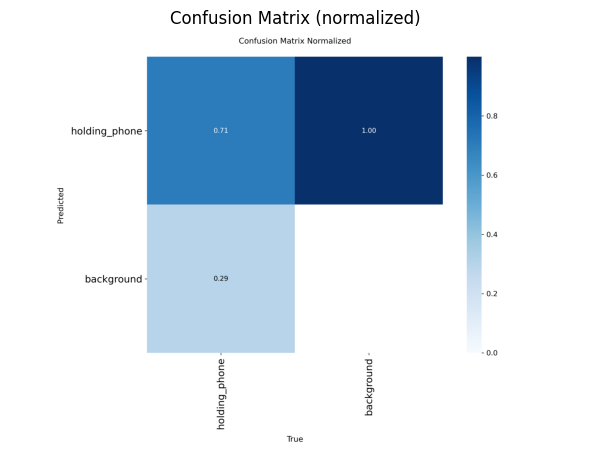

In [7]:
class_indices = val.box.ap_class_index.astype(int).tolist()
per_class = []
for i, ci in enumerate(class_indices):
    p, r, ap50, ap = val.box.class_result(i)
    per_class.append({'class': val.names[ci], 'Precision': float(p), 'Recall': float(r),
                      'mAP50': float(ap50), 'mAP50-95': float(ap)})
per_class_df = pd.DataFrame(per_class)
print(per_class_df.round(3).to_string(index=False))

cm_path = Path(val.save_dir) / 'confusion_matrix_normalized.png'
if cm_path.exists():
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(Image.open(cm_path)); ax.set_title('Confusion Matrix (normalized)'); ax.axis('off')
    plt.tight_layout(); plt.show()

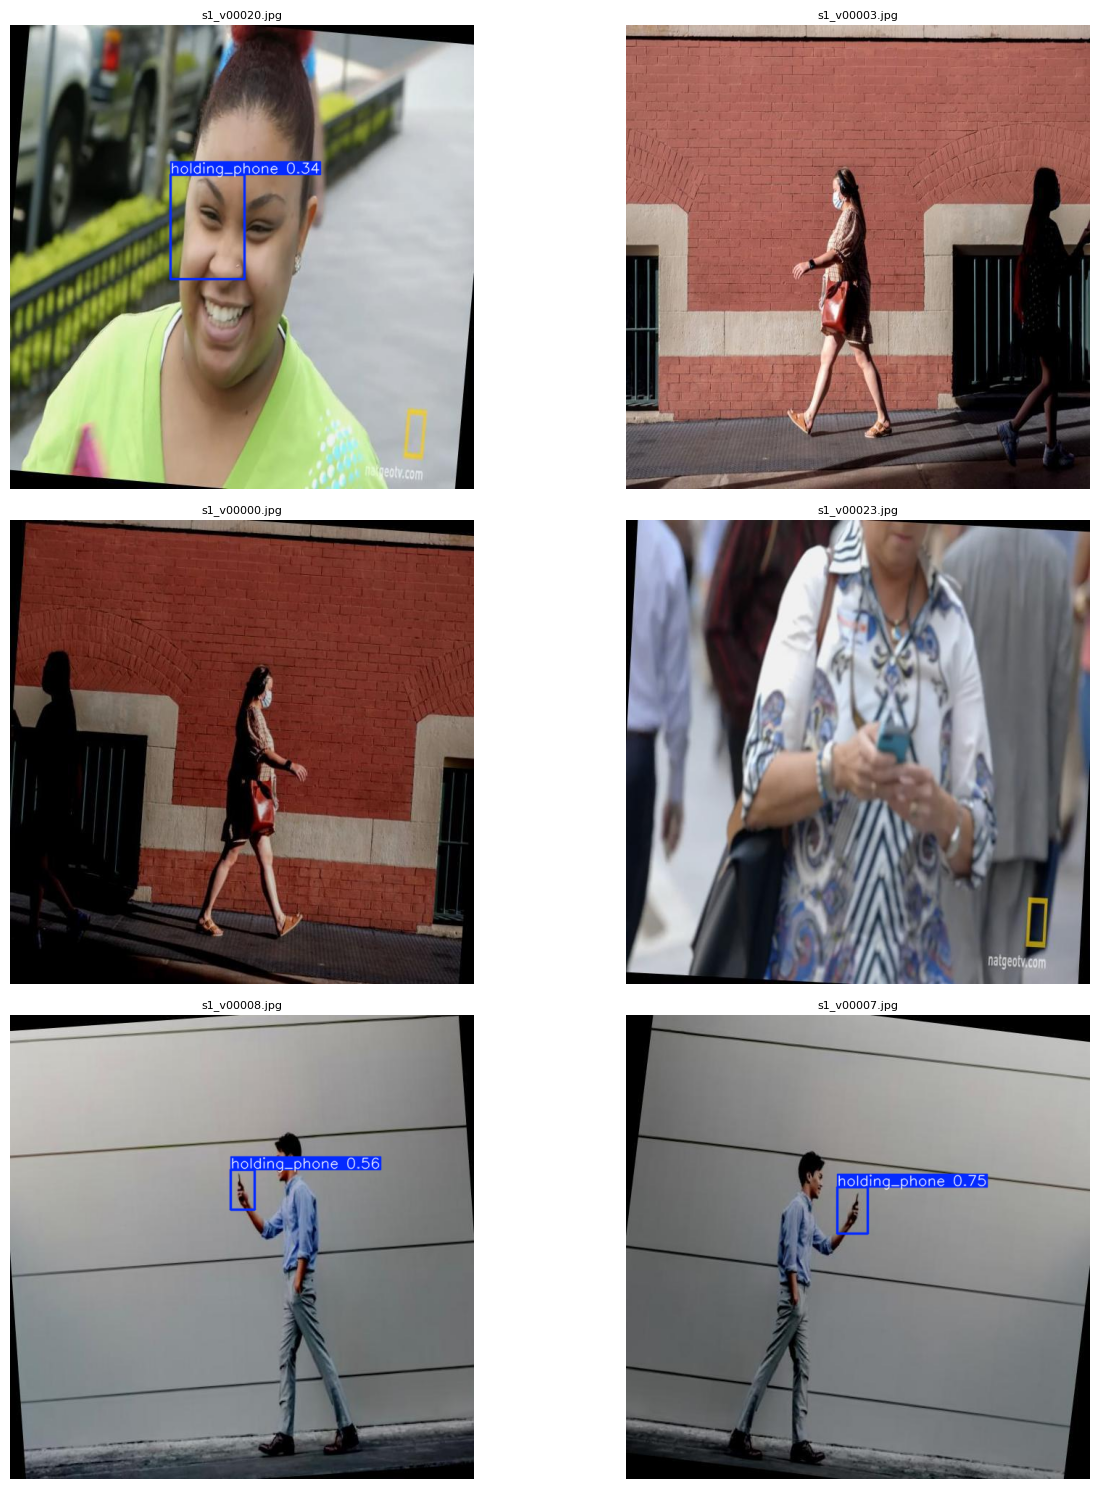

In [8]:
N = 6
val_dir = PROC_DIR / 'valid' / 'images'
imgs = []
for e in ('*.jpg', '*.jpeg', '*.png'):
    imgs.extend(sorted(val_dir.glob(e)))
samples = random.Random(SEED).sample(imgs, min(N, len(imgs)))
cols = 2
rows_n = (len(samples) + cols - 1) // cols
fig, axes = plt.subplots(rows_n, cols, figsize=(14, 5 * rows_n)); axes = axes.flatten()
for ax, ip in zip(axes, samples):
    r = eval_model.predict(str(ip), conf=0.25, imgsz=640, verbose=False)[0]
    ax.imshow(r.plot()[..., ::-1]); ax.set_title(ip.name[:40], fontsize=8); ax.axis('off')
for ax in axes[len(samples):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

## Simpan Artifact

In [9]:
import json
import torch

speed = getattr(val, 'speed', {}) or {}
total_ms = sum(float(speed.get(k, 0.0)) for k in ('preprocess', 'inference', 'postprocess'))
eval_report = {
    'model_key': 'holding_phone',
    'base_weight': str(BASE_MODEL),
    'run_dir': str(run_dir),
    'best_pt': str(best_pt),
    'data_yaml': str(DATA_YAML),
    'class_names': CLASS_NAMES,
    'seed': SEED,
    'train_cfg': TRAIN_CFG,
    'eval_cfg': {'conf': 0.25, 'imgsz': 640, 'split': 'val'},
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'metrics': {'mAP50': float(val.box.map50), 'mAP50-95': float(val.box.map),
                'precision': float(val.box.mp), 'recall': float(val.box.mr)},
    'speed_ms': {'total': total_ms, 'fps': (1000.0 / total_ms) if total_ms else 0.0},
}
(ARTIFACTS_DIR / 'eval_report.json').write_text(json.dumps(eval_report, indent=2), encoding='utf-8')
per_class_df.to_csv(ARTIFACTS_DIR / 'per_class_metrics.csv', index=False)
print('Saved ke', ARTIFACTS_DIR)

Saved ke c:\Users\istd.magang125\OneDrive - TMMIN\Documents\cctv-insight\ai\research\artifacts\holding_phone


## Cara Register ke Service

Setelah `best.pt` jadi & metrik oke, tambahkan ke [registry.py](../../../src/cctv_insight_ai/models/registry.py):

**1. `MODEL_REGISTRY`:**
```python
"holding_phone": ModelSpec(
    name="holding_phone_yolo26m",
    version="2026.06.20",
    weights_path=str(_RUNS_DIR / "holding_phone_yolo26m" / "weights" / "best.pt"),
    task_classes=[0],
    class_labels={0: ClassLabel("holding_phone")},
    description="Holding-phone detection (single class)",
),
```

**2. `CheckName` Literal:** tambah `"holding_phone_count",`

**3. `CHECK_DEFINITIONS`:**
```python
"holding_phone_count": CheckDefinition(
    name="holding_phone_count",
    model_key="holding_phone",
    categories=[CheckCategory(key="holding_phone", source_label="holding_phone")],
    description="Hitung orang memegang HP",
),
```

Lalu sync enum di `contracts/*.schema.json`, `pytest tests/`, dan smoke test gRPC.

> **Fase B ("sambil berjalan"):** gate walking sudah ada (`pipelines/tracking.py`). Violation `holding_phone_violation` hanya fire saat track-nya bergerak.